In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# -------------------------------
# Scikit-Learn (Machine Learning utilities)
# -------------------------------
from sklearn.model_selection import train_test_split
#  Splits the dataset into training and testing sets to evaluate model performance.

from sklearn.preprocessing import LabelEncoder, StandardScaler
# LabelEncoder: Converts categorical labels (e.g., "cat", "dog") into numeric values.
# StandardScaler: Normalizes/standardizes numerical features so they have mean=0 and variance=1.

from sklearn.linear_model import Perceptron
# A simple linear classifier (single-layer neural network). Good for binary classification tasks.

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# accuracy_score: Measures how many predictions are correct.
# classification_report: Shows precision, recall, and F1-score for each class.
# confusion_matrix: Shows where the model is making correct vs wrong predictions.

# -------------------------------
# TensorFlow / Keras (Deep Learning utilities)
# -------------------------------
import tensorflow as tf

from tensorflow.keras.models import Sequential
# Lets you build a neural network layer-by-layer in a linear fashion.

from tensorflow.keras.layers import Dense
# Fully connected layer (every neuron connects to every neuron in the next layer).

from tensorflow.keras.layers import Dropout
# Randomly drops some neurons during training to prevent overfitting.

from tensorflow.keras.utils import to_categorical
# 👉 Converts class labels (like 0, 1, 2) into one-hot encoded format (e.g., [1,0,0], [0,1,0]).


In [3]:
from sklearn.datasets import load_iris

In [7]:


iris = load_iris()

df = pd.DataFrame(iris.data, columns=[
    'SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm'
])

# Add species names
df['Species'] = [f'Iris-{iris.target_names[i]}' for i in iris.target]

# Add Id column starting from 1
df.insert(0, 'Id', range(1, len(df)+1))

print(df.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [10]:
df['Species'].value_counts()

,count
Species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


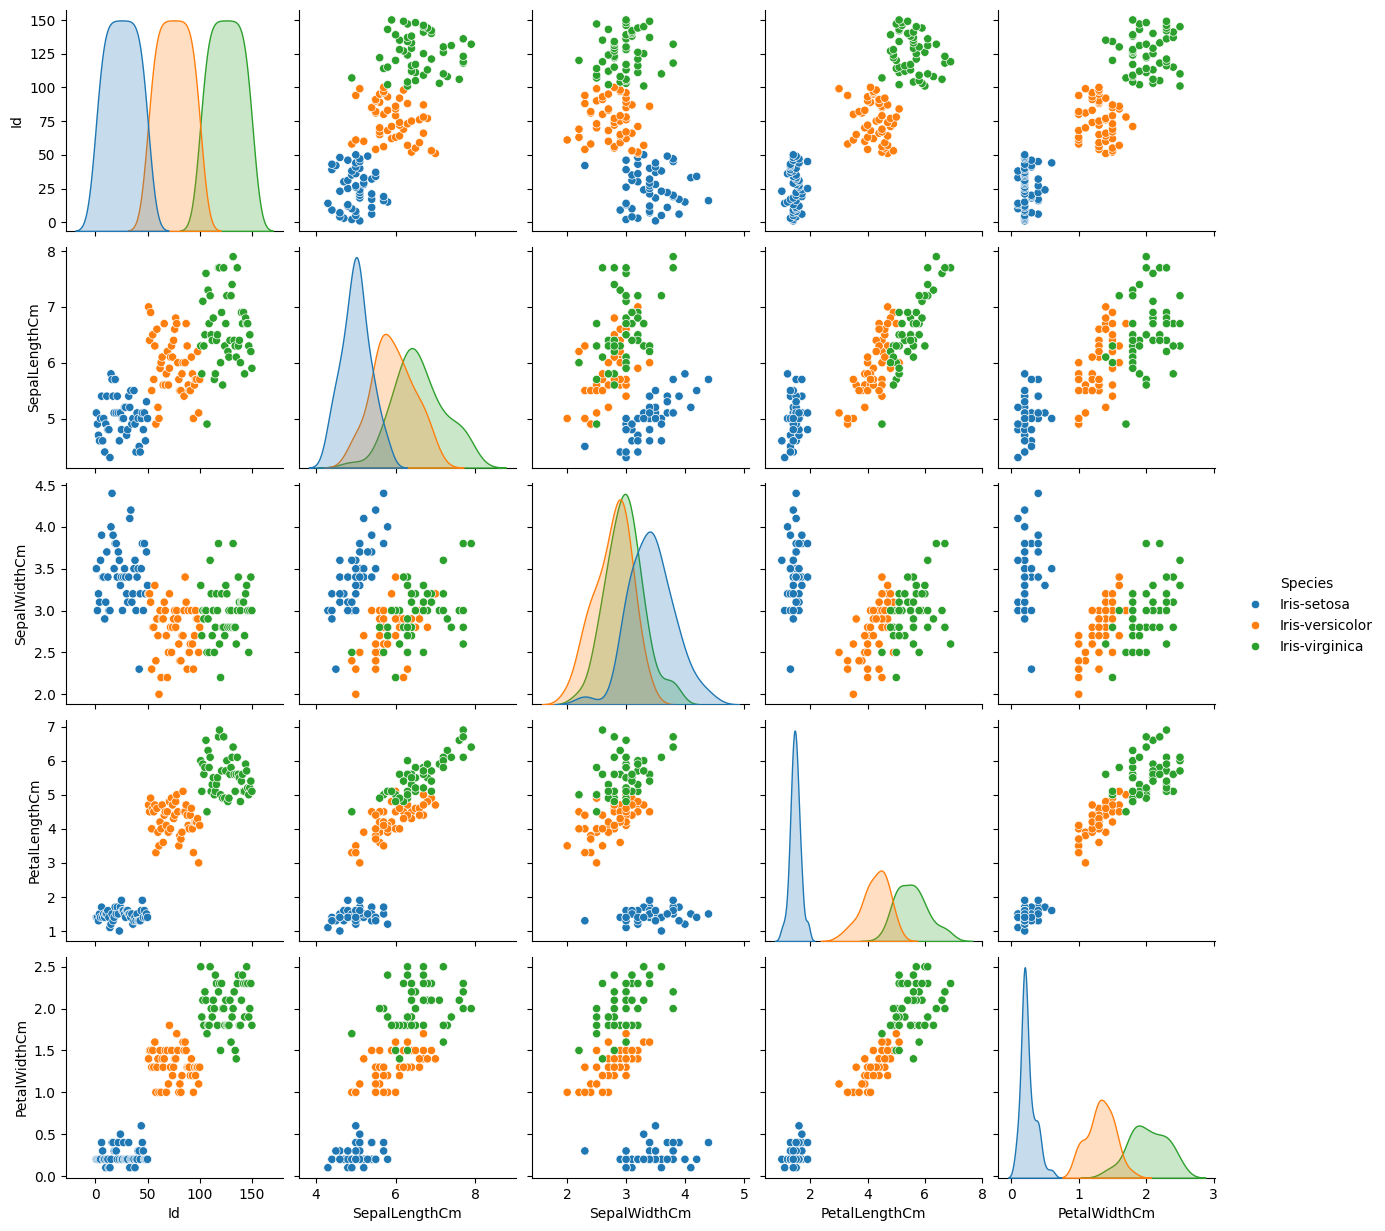

In [12]:
sns.pairplot(df,hue ='Species')

In [13]:
X = df.drop(columns= ['Species','Id'],axis = 1 )
y = df['Species']


In [14]:
encoder = LabelEncoder()
y_int = encoder.fit_transform(y)

In [15]:
y_int

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
...     X, y_int, test_size=0.2, random_state=42,stratify=y_int)

In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)


In [18]:
per = Perceptron(max_iter = 1000,random_state=42)
per.fit(X_train_scaled, y_train)

Perceptron(random_state=42)

In [19]:
y_pred_percep = per.predict(X_test_scaled)

In [20]:
accuracy_score(y_test,y_pred_percep)

0.9

In [21]:
print(classification_report(y_test,y_pred_percep))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.70      0.82        10
           2       0.77      1.00      0.87        10

    accuracy                           0.90        30
   macro avg       0.92      0.90      0.90        30
weighted avg       0.92      0.90      0.90        30



In [22]:
y_train_cat = to_categorical(y_train,num_classes = 3)
y_test_cat = to_categorical(y_test,num_classes = 3)

In [23]:
model = Sequential([
    Dense(16,input_dim = 4,activation='relu'),
    Dense(8,activation='relu'),
    Dense(3,activation='softmax')
])

In [24]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [25]:
history = model.fit(X_train_scaled,y_train_cat,
                    epochs = 100,batch_size= 8, validation_split = 0.2,verbose = 1)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.4737 - loss: 1.0481 - val_accuracy: 0.5833 - val_loss: 1.0183
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6964 - loss: 0.9686 - val_accuracy: 0.5833 - val_loss: 0.9723
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6931 - loss: 0.9186 - val_accuracy: 0.6250 - val_loss: 0.9314
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6231 - loss: 0.9065 - val_accuracy: 0.6667 - val_loss: 0.8956
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7128 - loss: 0.8432 - val_accuracy: 0.6250 - val_loss: 0.8601
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6852 - loss: 0.8153 - val_accuracy: 0.6250 - val_loss: 0.8258
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7446 - loss: 0.7276 - val_accuracy: 0.6250 - val_loss: 0.7880
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.6698 - loss: 0.7598 - val_accuracy: 0.

In [26]:
loss, acc = model.evaluate(X_test_scaled, y_test_cat, verbose=1)
print(acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.9333 - loss: 0.1198
0.9333333373069763


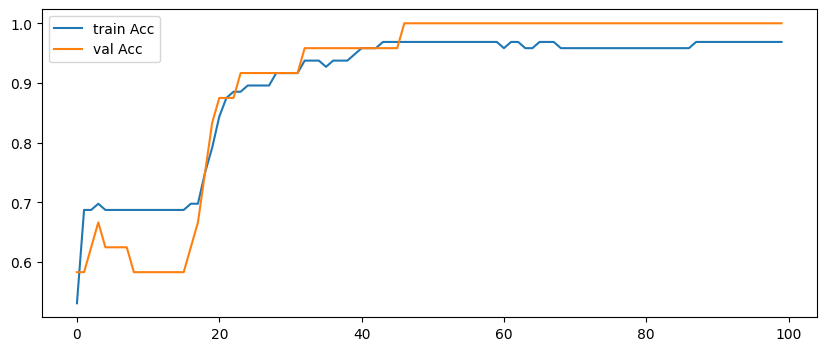

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label="train Acc")
plt.plot(history.history['val_accuracy'], label="val Acc")

plt.legend()
plt.show()